<a href="https://colab.research.google.com/github/Ariqueeezz/Enterprise-Brand-Sentiment-and-Campaign-Analytics-Pipeline/blob/epic%2FEBSCAP-9/Epic_EBSCAP_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving torch_ready_checkpoint (1).zip to torch_ready_checkpoint (1).zip


In [3]:
import zipfile
import os

torch_dir = "/content/torch_ready"
os.makedirs(torch_dir, exist_ok=True)

with zipfile.ZipFile("torch_ready_checkpoint.zip", "r") as zip_ref:
    zip_ref.extractall(torch_dir)

print("Isi folder torch_ready:")
print(os.listdir(torch_dir))

Isi folder torch_ready:
['word2idx.pkl', 'y_test.npy', 'X_val.npy', 'X_test.npy', 'y_val.npy', 'embedding_matrix.npy', 'X_train.npy', 'y_train.npy']


In [4]:
import numpy as np
import pickle
import torch
from torch.utils.data import Dataset, DataLoader

embedding_matrix = np.load(f"{torch_dir}/embedding_matrix.npy")
X_train = np.load(f"{torch_dir}/X_train.npy")
X_val = np.load(f"{torch_dir}/X_val.npy")
X_test = np.load(f"{torch_dir}/X_test.npy")
y_train = np.load(f"{torch_dir}/y_train.npy")
y_val = np.load(f"{torch_dir}/y_val.npy")
y_test = np.load(f"{torch_dir}/y_test.npy")

with open(f"{torch_dir}/word2idx.pkl", "rb") as f:
    word2idx = pickle.load(f)

print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Vocab size: {len(word2idx)}")

Embedding matrix shape: (47016, 100)
X_train shape: (489937, 100), y_train shape: (489937,)
Vocab size: 47016


# **EBSCAP-12: Rancang arsitektur model sekuensial (Bi-LSTM dengan Attention atau DistilBERT)**

In [5]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [6]:
class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE = 64
train_loader = DataLoader(SentimentDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SentimentDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(SentimentDataset(X_test, y_test), batch_size=BATCH_SIZE)

xb, yb = next(iter(train_loader))
print(f"Sanity check batch shape: {xb.shape}, {yb.shape}")

Sanity check batch shape: torch.Size([64, 100]), torch.Size([64])


In [7]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)  # *2 karena bidirectional

    def forward(self, lstm_output, mask):
        scores = self.attn(lstm_output).squeeze(-1)          # [batch, seq_len]
        scores = scores.masked_fill(mask == 0, -1e9)          # abaikan posisi PAD
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(lstm_output * weights.unsqueeze(-1), dim=1)
        return context, weights

In [8]:
class BiLSTMAttentionClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=128, num_classes=3,
                 num_layers=1, dropout=0.3, pad_idx=0):
        super().__init__()
        vocab_size, embedding_dim = embedding_matrix.shape

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=False,
            padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            embedding_dim, hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.attention = Attention(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.pad_idx = pad_idx

    def forward(self, x):
        mask = (x != self.pad_idx).float()
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        context, attn_weights = self.attention(lstm_out, mask)
        out = self.dropout(context)
        logits = self.fc(out)
        return logits, attn_weights

In [9]:
PAD_IDX = word2idx["<PAD>"]

model = BiLSTMAttentionClassifier(
    embedding_matrix=embedding_matrix,
    hidden_dim=128,
    num_classes=3,
    dropout=0.3,
    pad_idx=PAD_IDX
).to(device)

print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable_params:,}")

BiLSTMAttentionClassifier(
  (embedding): Embedding(47016, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)
Total params: 4,938,148 | Trainable: 4,938,148


In [10]:
xb, yb = xb.to(device), yb.to(device)

logits, attn_weights = model(xb)
print(f"Logits shape: {logits.shape}")                    # harus [64, 3]
print(f"Attention weights shape: {attn_weights.shape}")   # harus [64, 100]
print(f"Attention weights sum per sample (~1.0): {attn_weights.sum(dim=1)[:5]}")

Logits shape: torch.Size([64, 3])
Attention weights shape: torch.Size([64, 100])
Attention weights sum per sample (~1.0): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SliceBackward0>)


# **EBSCAP 13: Eksekusi training batch historis dan optimasi model**

In [11]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch.optim as optim
import copy

In [12]:
from collections import Counter

class_counts = Counter(y_train.tolist())
print(f"Distribusi kelas di training set: {class_counts}")

total = sum(class_counts.values())
class_weights = torch.tensor(
    [total / class_counts[i] for i in range(3)],
    dtype=torch.float32
).to(device)

print(f"Class weights: {class_weights}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Distribusi kelas di training set: Counter({2: 349140, 0: 101416, 1: 39381})
Class weights: tensor([ 4.8310, 12.4409,  1.4033])


In [13]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            logits, _ = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")  # macro: perlakukan tiap kelas setara
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")

    return avg_loss, acc, f1_macro, f1_weighted, all_preds, all_labels

In [14]:
NUM_EPOCHS = 20
PATIENCE = 3  # stop kalau val F1 macro tidak membaik selama 3 epoch berturut-turut

best_val_f1 = -1
patience_counter = 0
best_model_state = None

history = {
    "train_loss": [], "val_loss": [],
    "val_acc": [], "val_f1_macro": []
}

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # cegah exploding gradient
        optimizer.step()

        total_train_loss += loss.item() * xb.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    val_loss, val_acc, val_f1_macro, val_f1_weighted, _, _ = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1_macro"].append(val_f1_macro)

    print(f"Epoch {epoch:2d} | Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1 (macro): {val_f1_macro:.4f}")

    # Early stopping check
    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  → Model membaik, checkpoint disimpan.")
    else:
        patience_counter += 1
        print(f"  → Tidak membaik ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping dipicu di epoch {epoch}.")
            break

# Load kembali bobot terbaik (bukan bobot epoch terakhir)
model.load_state_dict(best_model_state)
print(f"\nBest Val F1 (macro): {best_val_f1:.4f}")

Epoch  1 | Train Loss: 0.6156 | Val Loss: 0.5763 | Val Acc: 0.7929 | Val F1 (macro): 0.6814
  → Model membaik, checkpoint disimpan.
Epoch  2 | Train Loss: 0.5210 | Val Loss: 0.5644 | Val Acc: 0.8292 | Val F1 (macro): 0.7035
  → Model membaik, checkpoint disimpan.
Epoch  3 | Train Loss: 0.4552 | Val Loss: 0.5926 | Val Acc: 0.8271 | Val F1 (macro): 0.6985
  → Tidak membaik (1/3)
Epoch  4 | Train Loss: 0.3880 | Val Loss: 0.6716 | Val Acc: 0.8294 | Val F1 (macro): 0.6953
  → Tidak membaik (2/3)
Epoch  5 | Train Loss: 0.3239 | Val Loss: 0.7991 | Val Acc: 0.8300 | Val F1 (macro): 0.6907
  → Tidak membaik (3/3)

Early stopping dipicu di epoch 5.

Best Val F1 (macro): 0.7035


In [15]:
test_loss, test_acc, test_f1_macro, test_f1_weighted, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

print(f"\n=== Hasil Test Set ===")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 (macro): {test_f1_macro:.4f}")
print(f"F1 (weighted): {test_f1_weighted:.4f}")

label_names = ["Negatif", "Netral", "Positif"]
print("\n" + classification_report(test_labels, test_preds, target_names=label_names))


=== Hasil Test Set ===
Accuracy: 0.8293
F1 (macro): 0.7046
F1 (weighted): 0.8511

              precision    recall  f1-score   support

     Negatif       0.82      0.77      0.80     21732
      Netral       0.30      0.61      0.40      8439
     Positif       0.97      0.87      0.92     74816

    accuracy                           0.83    104987
   macro avg       0.70      0.75      0.70    104987
weighted avg       0.89      0.83      0.85    104987



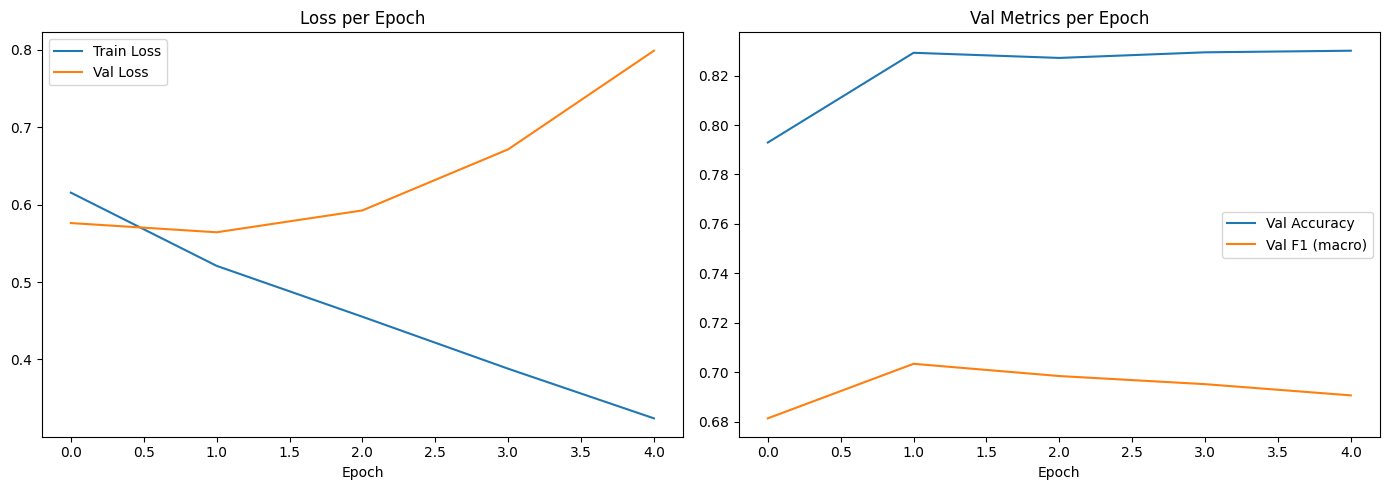

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["val_acc"], label="Val Accuracy")
axes[1].plot(history["val_f1_macro"], label="Val F1 (macro)")
axes[1].set_title("Val Metrics per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
model_dir = "/content/model_ready"
os.makedirs(model_dir, exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "hidden_dim": 128,
    "num_classes": 3,
    "dropout": 0.3,
    "pad_idx": PAD_IDX,
    "embedding_dim": embedding_matrix.shape[1],
    "vocab_size": embedding_matrix.shape[0],
}, f"{model_dir}/bilstm_attention_model.pt")

import pickle
with open(f"{model_dir}/training_history.pkl", "wb") as f:
    pickle.dump(history, f)

import shutil
from google.colab import files
shutil.make_archive("/content/model_ready_checkpoint", "zip", model_dir)
files.download("/content/model_ready_checkpoint.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>